In [11]:
import requests
import pandas as pd
import os
import requests
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("EIA_API_KEY")

BASE_URL = "https://api.eia.gov/v2"

DATA_URL = (
    f"{BASE_URL}/electricity/rto/"
    "region-data/data/"
)

params = {
    "api_key": API_KEY,
    "frequency": "hourly",
    "data[0]": "value",

    # California ISO
    "facets[respondent][]": "CISO",

    # Actual demand
    "facets[type][]": "D",

    "start": "2026-08-01T00",
    "end": "2026-08-26T00",

    "sort[0][column]": "period",
    "sort[0][direction]": "asc",

    "offset": 0,
    "length": 5000
}

response = requests.get(
    DATA_URL,
    params=params,
    timeout=30
)

response.raise_for_status()

result = response.json()

print("Total rows:", result["response"]["total"])

result["response"]["data"][:5]

Total rows: 601


[{'period': '2026-08-01T00',
  'respondent': 'CISO',
  'respondent-name': 'California Independent System Operator',
  'type': 'D',
  'type-name': 'Demand',
  'value': '40140',
  'value-units': 'megawatthours'},
 {'period': '2026-08-01T01',
  'respondent': 'CISO',
  'respondent-name': 'California Independent System Operator',
  'type': 'D',
  'type-name': 'Demand',
  'value': '41025',
  'value-units': 'megawatthours'},
 {'period': '2026-08-01T02',
  'respondent': 'CISO',
  'respondent-name': 'California Independent System Operator',
  'type': 'D',
  'type-name': 'Demand',
  'value': '41356',
  'value-units': 'megawatthours'},
 {'period': '2026-08-01T03',
  'respondent': 'CISO',
  'respondent-name': 'California Independent System Operator',
  'type': 'D',
  'type-name': 'Demand',
  'value': '40534',
  'value-units': 'megawatthours'},
 {'period': '2026-08-01T04',
  'respondent': 'CISO',
  'respondent-name': 'California Independent System Operator',
  'type': 'D',
  'type-name': 'Demand',


In [12]:
df = pd.DataFrame(
    result["response"]["data"]
)

df.head()

,period,respondent,respondent-name,type,type-name,value,value-units
0,2026-08-01T00,CISO,California Independent System Operator,D,Demand,40140,megawatthours
1,2026-08-01T01,CISO,California Independent System Operator,D,Demand,41025,megawatthours
2,2026-08-01T02,CISO,California Independent System Operator,D,Demand,41356,megawatthours
3,2026-08-01T03,CISO,California Independent System Operator,D,Demand,40534,megawatthours
4,2026-08-01T04,CISO,California Independent System Operator,D,Demand,38947,megawatthours


In [13]:
df.tail()

,period,respondent,respondent-name,type,type-name,value,value-units
596,2026-08-25T20,CISO,California Independent System Operator,D,Demand,38747,megawatthours
597,2026-08-25T21,CISO,California Independent System Operator,D,Demand,39409,megawatthours
598,2026-08-25T22,CISO,California Independent System Operator,D,Demand,40581,megawatthours
599,2026-08-25T23,CISO,California Independent System Operator,D,Demand,42613,megawatthours
600,2026-08-26T00,CISO,California Independent System Operator,D,Demand,44013,megawatthours


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   period           601 non-null    object
 1   respondent       601 non-null    object
 2   respondent-name  601 non-null    object
 3   type             601 non-null    object
 4   type-name        601 non-null    object
 5   value            601 non-null    object
 6   value-units      601 non-null    object
dtypes: object(7)
memory usage: 33.0+ KB


In [15]:
df["period"] = pd.to_datetime(
    df["period"],
    utc=True
)

df["value"] = pd.to_numeric(
    df["value"],
    errors="coerce"
)

df = (
    df
    .sort_values("period")
    .reset_index(drop=True)
)

In [16]:
df["gap_hours"] = (
    df["period"]
    .diff()
    .dt.total_seconds()
    / 3600
)

df["gap_hours"].value_counts().sort_index()

gap_hours
1.0    600
Name: count, dtype: int64

In [17]:
print(
    "Duplicate timestamps:",
    df["period"].duplicated().sum()
)

Duplicate timestamps: 0


In [18]:
print(
    "Missing demand:",
    df["value"].isna().sum()
)

Missing demand: 0


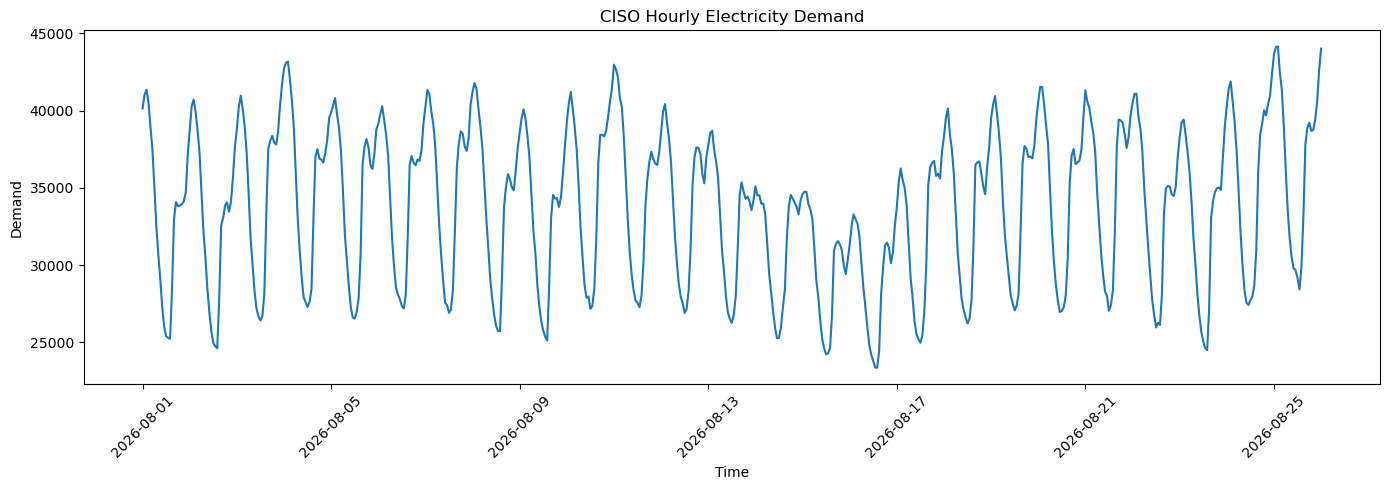

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    df["period"],
    df["value"]
)

plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("CISO Hourly Electricity Demand")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
df["target_demand_1h"] = (
    df["value"].shift(-1)
)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   period            601 non-null    datetime64[ns, UTC]
 1   respondent        601 non-null    object             
 2   respondent-name   601 non-null    object             
 3   type              601 non-null    object             
 4   type-name         601 non-null    object             
 5   value             601 non-null    int64              
 6   value-units       601 non-null    object             
 7   gap_hours         600 non-null    float64            
 8   target_demand_1h  600 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(2), int64(1), object(5)
memory usage: 42.4+ KB
